# Predicting Pile Bearing Capacity using MLP

This notebook demonstrates **function approximation** using a Multi-Layer Perceptron (MLP) in PyTorch. We'll predict pile bearing capacity from geotechnical features.

**Goal**: Learn the nonlinear mapping from pile geometry and soil properties → bearing capacity

**Note**: For detailed MLP concepts (activation functions, architectures, etc.), see `03a-mlp-classification.ipynb`

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/03-mlp/03b-mlp-pile-capacity-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/03-mlp/03b-mlp-pile-capacity.ipynb)

## Input Features

The dataset holds 100 rows from PHC nodular pile load tests in Vietnam, covering 88
distinct pile configurations. Eleven rows repeat another row's inputs with a different
measured capacity. The CSV carries ten `X` columns. Two of them are linear combinations
of the others, so the source paper's network takes eight inputs, not ten. This notebook
keeps all ten and says where the redundancy is.

Ranges below come from `df.describe()` on the shipped CSV.

### Pile Geometry:
- **Pile_Diameter** (m): Cross-sectional diameter (0.30-0.40 m)
- **Tip_Length** (m): Length of bottom segment (3.40-5.40 m)
- **Middle_Length** (m): Length of middle segment (1.71-8.00 m)
- **Top_Length** (m): Length of top segment (0.00-1.22 m)

### Elevations:
- **Ground_Elev** (m): Natural ground surface (1.95-3.40 m)
- **Pile_Top_Elev** (m): Pile head elevation (3.26-3.70 m)
- **Guide_Stop_Elev** (m): Guide stop elevation (1.06-3.68 m)
- **Pile_Tip_Depth** (m): Ground elevation plus the three segment lengths,
  `X5 + X2 + X3 + X4` (8.51-15.62 m). This is a depth below the pile head, not an
  elevation on the same datum as Ground_Elev, which is why its range sits above the
  other three. It is a deterministic function of four other inputs and carries no new
  information

### Pile Length:
- **Pile_Length** (m): Total pile length, `X2 + X3 + X4` (5.81-14.70 m). The identity
  holds in 99 of the 100 rows. Row 24 is the one exception

### Soil Strength:
- **SPT_Tip**: Average SPT N-value at pile tip (4.56-7.75)

### Target:
- **Bearing_Capacity** (MN): Measured axial capacity (0.4239-1.5510 MN)

**Reference**: Nguyen, T., Ly, K.-D., Nguyen-Thoi, T., Nguyen, B.-P., and Doan, N.-P.
(2022). "Prediction of axial load bearing capacity of PHC nodular pile using Bayesian
regularization artificial neural network." *Soils and Foundations*, 62(5), 101203.
[doi:10.1016/j.sandf.2022.101203](https://doi.org/10.1016/j.sandf.2022.101203)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Load and Prepare Data

In [2]:
# Fetch the CSV only when it is not already next to the notebook.
# In this repo the file ships in docs/03-mlp, so nothing is downloaded.
from pathlib import Path

CSV = Path('pile_bearing_capacity.csv')
URL = 'https://raw.githubusercontent.com/kks32-courses/ai-geotech/main/docs/03-mlp/pile_bearing_capacity.csv'
if not CSV.exists():
    !wget -O pile_bearing_capacity.csv $URL
print(f"Using {CSV} ({CSV.stat().st_size} bytes)")


Using pile_bearing_capacity.csv (108212 bytes)


In [3]:
# Load the dataset
df = pd.read_csv('pile_bearing_capacity.csv')

# Define meaningful column names mapping
column_mapping = {
    'X1': 'Pile_Diameter',
    'X2': 'Tip_Length',
    'X3': 'Middle_Length',
    'X4': 'Top_Length',
    'X5': 'Ground_Elev',
    'X6': 'Pile_Top_Elev',
    'X7': 'Guide_Stop_Elev',
    'X8': 'Pile_Tip_Depth',
    'X9': 'Pile_Length',
    'X10': 'SPT_Tip',
    'Pu_Experiment': 'Bearing_Capacity'
}

# Rename columns
df = df.rename(columns=column_mapping)

# Select features and target
feature_columns = ['Pile_Diameter', 'Tip_Length', 'Middle_Length', 'Top_Length',
                   'Ground_Elev', 'Pile_Top_Elev', 'Guide_Stop_Elev', 'Pile_Tip_Depth',
                   'Pile_Length', 'SPT_Tip']

# Pile_Length = Tip_Length + Middle_Length + Top_Length and
# Pile_Tip_Depth = Ground_Elev + Pile_Length, in 99 of the 100 rows.
redundancy = (df['Pile_Length'] - df[['Tip_Length', 'Middle_Length', 'Top_Length']].sum(axis=1)).abs()
print(f"Rows where Pile_Length != Tip + Middle + Top: {(redundancy > 1e-9).sum()}")
target_column = 'Bearing_Capacity'

# Create feature matrix X and target vector y
X = df[feature_columns].values
y = df[target_column].values.reshape(-1, 1)  # Reshape for PyTorch

print(f"Dataset shape: {df.shape}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst 5 samples:")
df[feature_columns + [target_column]].head()

Rows where Pile_Length != Tip + Middle + Top: 1
Dataset shape: (100, 65)
Features shape: (100, 10)
Target shape: (100, 1)

First 5 samples:


,Pile_Diameter,Tip_Length,Middle_Length,Top_Length,Ground_Elev,Pile_Top_Elev,Guide_Stop_Elev,Pile_Tip_Depth,Pile_Length,SPT_Tip,Bearing_Capacity
0,0.4,4.35,8.00,1.0,2.05,3.48,2.08,15.40,13.35,7.631086,1.3950
1,0.3,3.40,5.25,0.0,3.40,3.47,3.42,12.05,8.65,6.750000,0.5598
2,0.3,3.40,5.30,0.0,3.40,3.52,3.42,12.10,8.70,6.760000,0.5089
3,0.4,4.25,8.00,0.9,2.15,3.56,2.26,15.30,13.15,7.610000,1.3950
4,0.4,3.40,7.30,0.0,3.40,3.49,3.39,14.10,10.70,7.280000,1.0688


In [4]:
# Summary statistics for the ten features and the target
print("Summary Statistics:")
print("="*80)
print()
df[feature_columns + [target_column]].describe()

Summary Statistics:



,Pile_Diameter,Tip_Length,Middle_Length,Top_Length,Ground_Elev,Pile_Top_Elev,Guide_Stop_Elev,Pile_Tip_Depth,Pile_Length,SPT_Tip,Bearing_Capacity
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.365000,3.869500,6.65720,0.340500,2.766000,3.500700,2.901400,13.625700,10.897200,7.065517,1.017400
std,0.047937,0.498325,1.57255,0.457011,0.618849,0.072756,0.620904,1.738287,2.245025,0.639656,0.362428
min,0.300000,3.400000,1.71000,0.000000,1.950000,3.260000,1.060000,8.510000,5.810000,4.560000,0.423900
25%,0.300000,3.400000,5.25000,0.000000,2.050000,3.450000,2.150000,12.050000,8.650000,6.750000,0.610700
50%,0.400000,3.650000,7.30000,0.000000,2.950000,3.490000,3.320000,14.100000,11.275000,7.180000,1.128600
75%,0.400000,4.350000,8.00000,0.902500,3.400000,3.550000,3.420000,15.302500,13.250000,7.603383,1.344000
max,0.400000,5.400000,8.00000,1.220000,3.400000,3.700000,3.680000,15.620000,14.700000,7.750000,1.551000


## 3. Three-Way Data Split: Train / Validation / Test

Eleven rows repeat another row's feature vector. A plain random split puts some of those
twins in different folds, and the test score then measures memorisation. We split on the
feature vector instead, so every copy of a configuration lands in the same fold.

- **Training Set (about 70%)**: Used to train the model (update weights)
- **Validation Set (about 15%)**: Used to monitor performance during training and pick
  the checkpoint
- **Testing Set (about 15%)**: Final evaluation on configurations the model never saw

The fractions are approximate because whole configurations move together.


In [5]:
# Group identical feature vectors so repeated configurations stay in one fold
groups = df[feature_columns].round(6).astype(str).agg('|'.join, axis=1).factorize()[0]
print(f"Distinct pile configurations: {groups.max() + 1} in {len(df)} rows")

# First split: separate test set (about 15% of the configurations)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
temp_idx, test_idx = next(gss_test.split(X, y, groups))

# Second split: separate train and validation from the remaining configurations
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
tr, va = next(gss_val.split(X[temp_idx], y[temp_idx], groups[temp_idx]))
train_idx, val_idx = temp_idx[tr], temp_idx[va]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Data Split Summary:")
print("="*80)
print(f"Total samples:      {len(X)}")
print(f"Training samples:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing samples:    {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Confirm no configuration crosses a fold boundary
as_set = lambda idx: set(map(tuple, X[idx]))
print(f"\nShared configurations, train and test: {len(as_set(train_idx) & as_set(test_idx))}")
print(f"Shared configurations, train and val:  {len(as_set(train_idx) & as_set(val_idx))}")

print(f"\nTraining set - Target statistics:")
print(f"  Mean: {y_train.mean():.4f} MN, Std: {y_train.std():.4f} MN")
print(f"Validation set - Target statistics:")
print(f"  Mean: {y_val.mean():.4f} MN, Std: {y_val.std():.4f} MN")
print(f"Testing set - Target statistics:")
print(f"  Mean: {y_test.mean():.4f} MN, Std: {y_test.std():.4f} MN")


Distinct pile configurations: 88 in 100 rows
Data Split Summary:
Total samples:      100
Training samples:   71 (71.0%)
Validation samples: 15 (15.0%)
Testing samples:    14 (14.0%)

Shared configurations, train and test: 0
Shared configurations, train and val:  0

Training set - Target statistics:
  Mean: 0.9901 MN, Std: 0.3583 MN
Validation set - Target statistics:
  Mean: 1.0293 MN, Std: 0.3419 MN
Testing set - Target statistics:
  Mean: 1.1431 MN, Std: 0.3646 MN


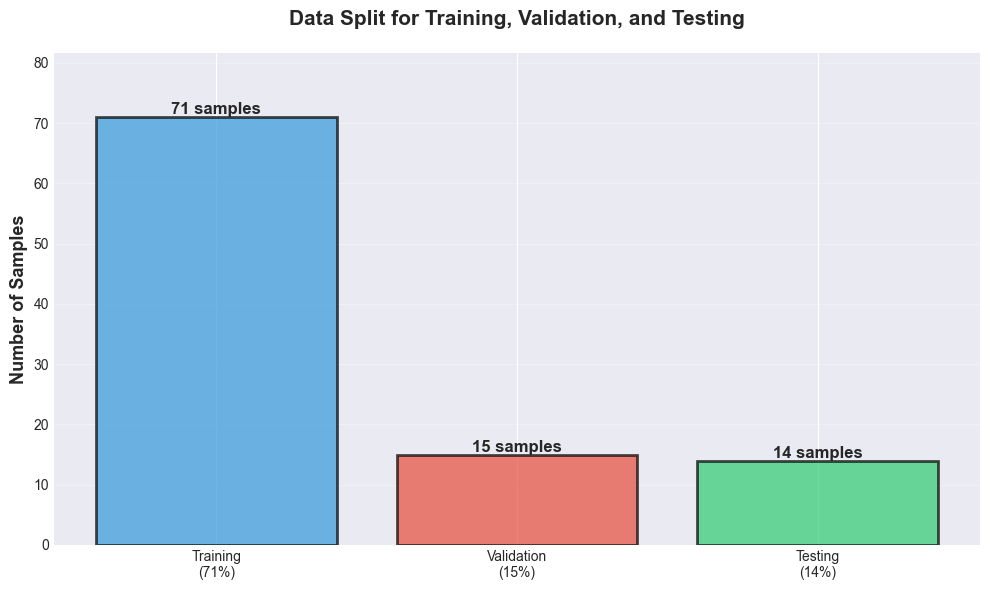

In [6]:
# Visualize the data split
fig, ax = plt.subplots(figsize=(10, 6))

sizes = [len(X_train), len(X_val), len(X_test)]
total = sum(sizes)
splits = [f'{name}\n({n/total*100:.0f}%)' for name, n in
          zip(['Training', 'Validation', 'Testing'], sizes)]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(splits, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{size} samples',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
ax.set_title('Data Split for Training, Validation, and Testing', fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(sizes) * 1.15)

plt.tight_layout()
plt.show()

## 4. Feature Scaling

Neural networks perform better when features are normalized to similar scales.

In [7]:
# Feature scaling - Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied successfully!")
print(f"\nScaled training data - Feature means (should be ~0):")
print(f"  {X_train_scaled.mean(axis=0)}")
print(f"\nScaled training data - Feature stds (should be ~1):")
print(f"  {X_train_scaled.std(axis=0)}")

Scaling applied successfully!

Scaled training data - Feature means (should be ~0):
  [ 8.38140199e-16  2.22826452e-15 -2.40808938e-16 -3.12738880e-17
 -2.68173590e-15 -2.37994288e-15  2.39245243e-16  2.62857029e-15
 -7.19299424e-17 -2.19542694e-15]

Scaled training data - Feature stds (should be ~1):
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Convert to PyTorch Tensors

In [8]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print("PyTorch tensors created:")
print(f"X_train shape: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}, device: {X_train_tensor.device}")
print(f"y_train shape: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}, device: {y_train_tensor.device}")
print(f"X_val shape:   {X_val_tensor.shape}, dtype: {X_val_tensor.dtype}, device: {X_val_tensor.device}")
print(f"X_test shape:  {X_test_tensor.shape}, dtype: {X_test_tensor.dtype}, device: {X_test_tensor.device}")

PyTorch tensors created:
X_train shape: torch.Size([71, 10]), dtype: torch.float32, device: cpu
y_train shape: torch.Size([71, 1]), dtype: torch.float32, device: cpu
X_val shape:   torch.Size([15, 10]), dtype: torch.float32, device: cpu
X_test shape:  torch.Size([14, 10]), dtype: torch.float32, device: cpu


In [9]:
# Create DataLoaders for batch processing

# Set batch size
batch_size = 16

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch_size={batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

DataLoaders created with batch_size=16
Training batches: 5
Validation batches: 1
Testing batches: 1


## 6. Build the MLP


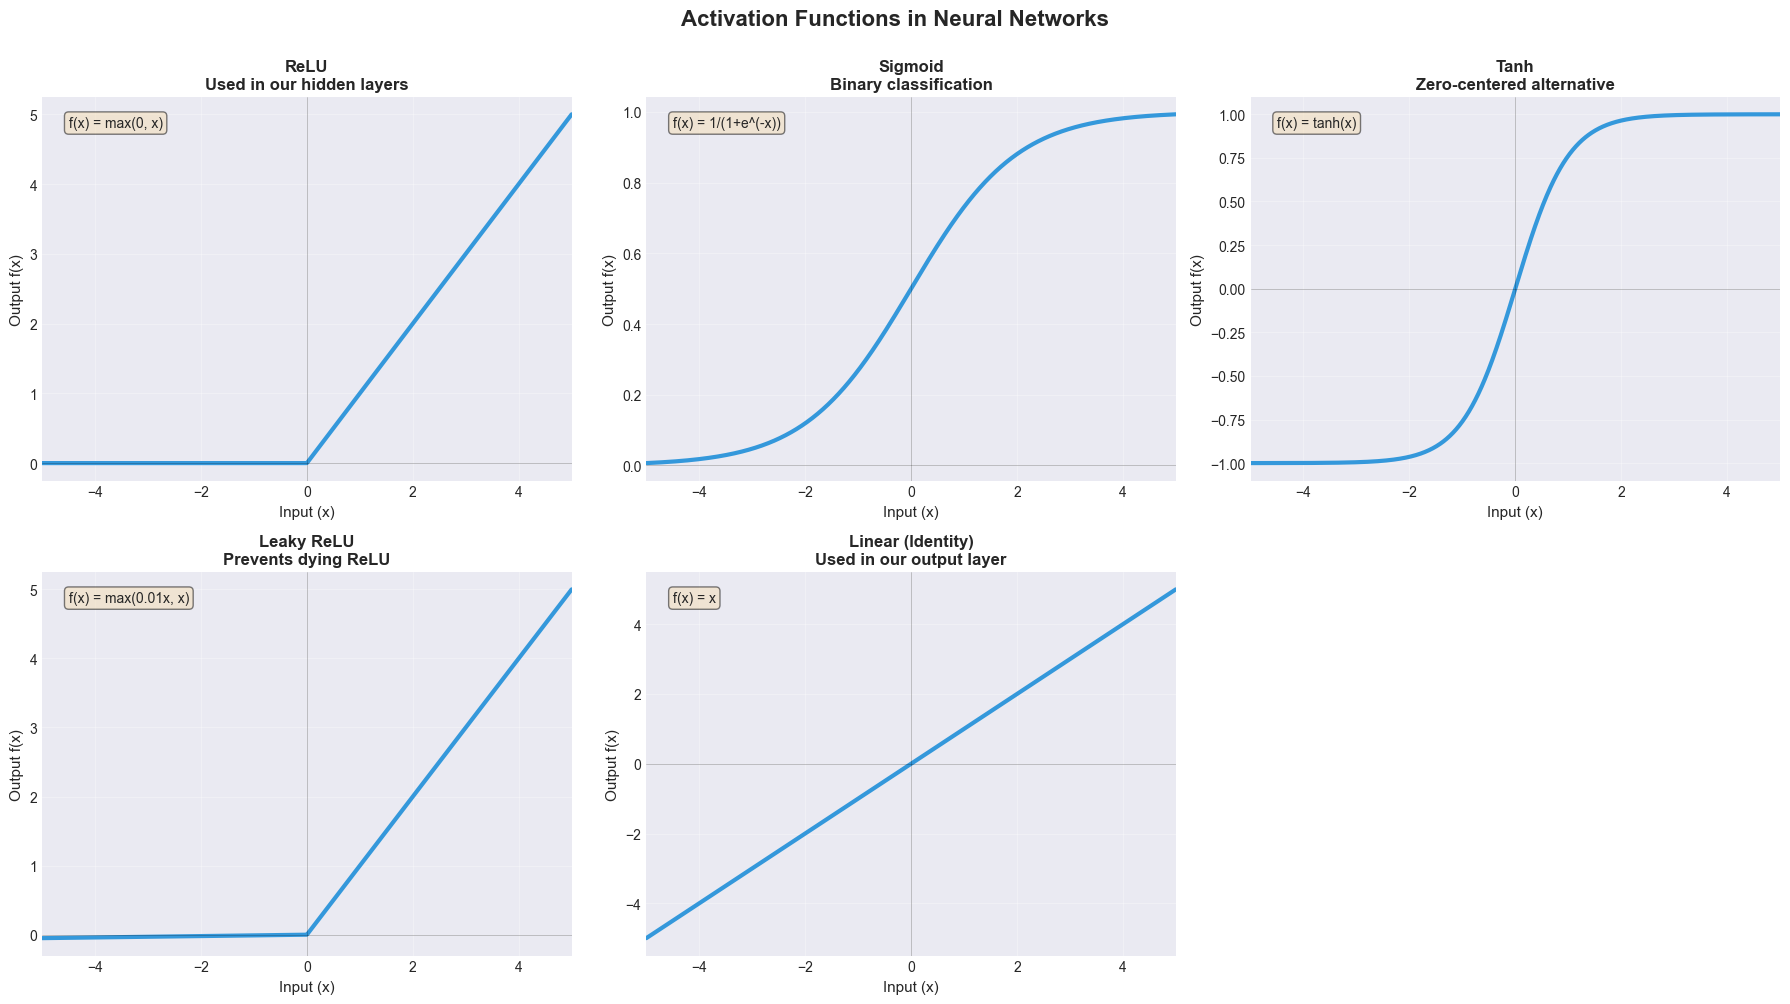

Our MLP Architecture will use:
  - ReLU activation in hidden layers (non-linear, prevents vanishing gradients)
  - Linear (Identity) activation in output layer (regression task)


In [10]:
# Activation functions used in the network below.
# 03a-mlp-classification.ipynb covers their properties in detail.
x = np.linspace(-5, 5, 1000)

# Define activation functions
relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh = lambda x: np.tanh(x)
leaky_relu = lambda x: np.where(x > 0, x, 0.01 * x)
linear = lambda x: x

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

activations = [
    (relu, 'ReLU', 'Used in our hidden layers'),
    (sigmoid, 'Sigmoid', 'Binary classification'),
    (tanh, 'Tanh', 'Zero-centered alternative'),
    (leaky_relu, 'Leaky ReLU', 'Prevents dying ReLU'),
    (linear, 'Linear (Identity)', 'Used in our output layer'),
]

for idx, (func, name, desc) in enumerate(activations):
    y = func(x)
    axes[idx].plot(x, y, linewidth=3, color='#3498db')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlabel('Input (x)', fontsize=11)
    axes[idx].set_ylabel('Output f(x)', fontsize=11)
    axes[idx].set_title(f'{name}\n{desc}', fontsize=12, fontweight='bold')
    axes[idx].set_xlim(-5, 5)

    # Add formula
    if name == 'ReLU':
        formula = 'f(x) = max(0, x)'
    elif name == 'Sigmoid':
        formula = 'f(x) = 1/(1+e^(-x))'
    elif name == 'Tanh':
        formula = 'f(x) = tanh(x)'
    elif name == 'Leaky ReLU':
        formula = 'f(x) = max(0.01x, x)'
    else:
        formula = 'f(x) = x'

    axes[idx].text(0.05, 0.95, formula, transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove the last unused subplot
fig.delaxes(axes[5])

plt.suptitle('Activation Functions in Neural Networks', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Our MLP Architecture will use:")
print("  - ReLU activation in hidden layers (non-linear, prevents vanishing gradients)")
print("  - Linear (Identity) activation in output layer (regression task)")

In [11]:
class PileBearingCapacityMLP(nn.Module):
    """
    Multi-Layer Perceptron for Pile Bearing Capacity Prediction

    Architecture:
    - Input: 10 features
    - Hidden 1: 64 neurons (ReLU + Dropout 0.2)
    - Hidden 2: 32 neurons (ReLU + Dropout 0.2)
    - Hidden 3: 16 neurons (ReLU + Dropout 0.1)
    - Output: 1 neuron (Linear)
    """
    def __init__(self, input_size=10, hidden_sizes=[64, 32, 16], dropout_rates=[0.2, 0.2, 0.1]):
        super(PileBearingCapacityMLP, self).__init__()

        # Layer 1: Input -> Hidden 1
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rates[0])

        # Layer 2: Hidden 1 -> Hidden 2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rates[1])

        # Layer 3: Hidden 2 -> Hidden 3
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_rates[2])

        # Output Layer: Hidden 3 -> Output
        self.fc4 = nn.Linear(hidden_sizes[2], 1)
        # No activation function here (linear output for regression)

    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)      # Linear transformation
        x = self.relu1(x)    # ReLU activation
        x = self.dropout1(x) # Dropout regularization

        x = self.fc2(x)      # Linear transformation
        x = self.relu2(x)    # ReLU activation
        x = self.dropout2(x) # Dropout regularization

        x = self.fc3(x)      # Linear transformation
        x = self.relu3(x)    # ReLU activation
        x = self.dropout3(x) # Dropout regularization

        x = self.fc4(x)      # Output layer (linear)

        return x

    def count_parameters(self):
        """Count total trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Create the model
model = PileBearingCapacityMLP(
    input_size=10,
    hidden_sizes=[64, 32, 16],
    dropout_rates=[0.2, 0.2, 0.1]
).to(device)

# Print model architecture
print("="*80)
print("MLP Architecture Summary")
print("="*80)
print(model)
print("="*80)
print(f"Total trainable parameters: {model.count_parameters():,}")
print("="*80)

# Print layer-by-layer details
print("\nLayer Details:")
print("-"*80)
for name, param in model.named_parameters():
    print(f"{name:20s} | Shape: {str(param.shape):20s} | Parameters: {param.numel():,}")
print("-"*80)

MLP Architecture Summary
PileBearingCapacityMLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.1, inplace=False)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
)
Total trainable parameters: 3,329

Layer Details:
--------------------------------------------------------------------------------
fc1.weight           | Shape: torch.Size([64, 10]) | Parameters: 640
fc1.bias             | Shape: torch.Size([64])     | Parameters: 64
fc2.weight           | Shape: torch.Size([32, 64]) | Parameters: 2,048
fc2.bias             | Shape: torch.Size([32])     | Parameters: 32
fc3.weight           | Shape: torch.Size([16, 32]) | Parameters: 512
fc3.bias             | Shape: torch.Size([16])  

## 7. Define Loss Function and Optimizer

For regression tasks:
- **Loss Function**: Mean Squared Error (MSE)
- **Optimizer**: Adam (Adaptive Moment Estimation)

In [12]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train the model for one epoch"""
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

def validate_epoch(model, val_loader, criterion, device):
    """Validate the model for one epoch"""
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(val_loader.dataset)
    return epoch_loss

print("Loss function, optimizer, and scheduler configured.")
print(f"Criterion: MSE Loss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=20)")

Loss function, optimizer, and scheduler configured.
Criterion: MSE Loss
Optimizer: Adam (lr=0.001, weight_decay=1e-5)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=20)


## 8. Training Loop with Validation Monitoring

The checkpoint saved here is the one with the lowest validation loss. The validation
score reported later is therefore a selection statistic, not an estimate of performance
on unseen data. Only the test score is held out.


In [13]:
# Training configuration
num_epochs = 500
patience = 50  # Early stopping patience

best_val_loss = float('inf')
epochs_without_improvement = 0

# Lists to store losses
train_losses = []
val_losses = []

print("Starting training...")
print("="*80)

# Training loop
for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    # Validate
    val_loss = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    # Learning rate scheduler step
    scheduler.step(val_loss)

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f}")
        break

print("="*80)
print("Training completed!")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final val loss: {val_losses[-1]:.6f}")
print(f"Best val loss: {best_val_loss:.6f}")

# Load best model
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
print("\nLoaded best model weights.")

Starting training...


Epoch [ 50/500] | Train Loss: 0.028220 | Val Loss: 0.018073 | LR: 0.001000

Early stopping triggered at epoch 95
Best validation loss: 0.014648
Training completed!
Final train loss: 0.027991
Final val loss: 0.016694
Best val loss: 0.014648

Loaded best model weights.


## 9. Visualize Training Progress


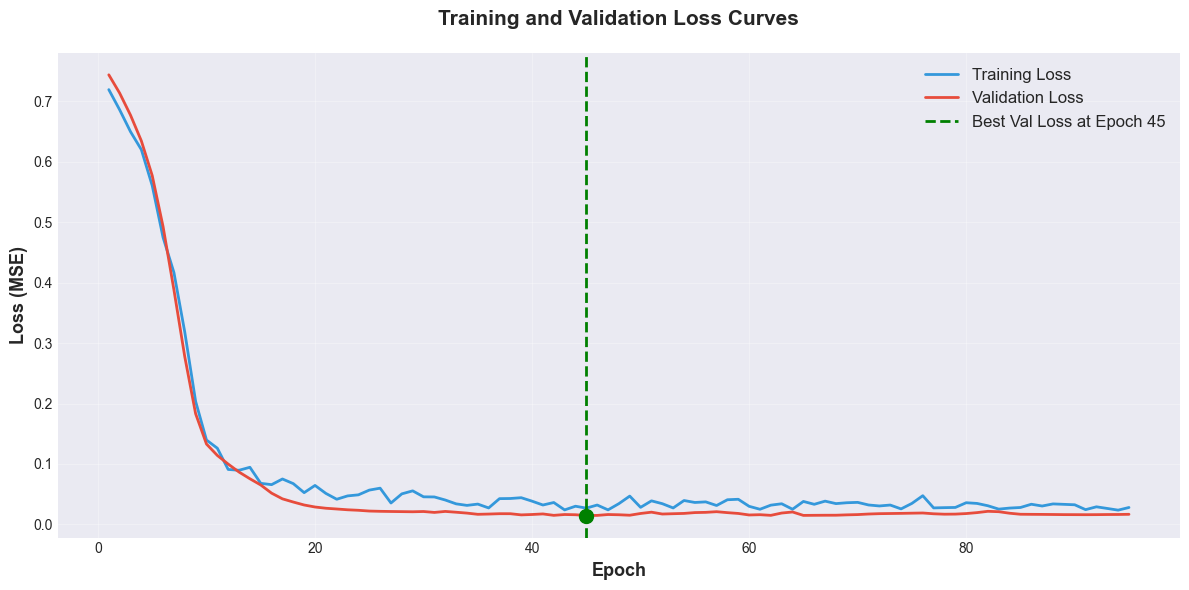

Best validation loss: 0.014648 at epoch 45
Final training loss: 0.027991
Final validation loss: 0.016694


In [14]:
# Plot training and validation loss
fig, ax = plt.subplots(figsize=(12, 6))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Training Loss', linewidth=2, color='#3498db')
ax.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2, color='#e74c3c')

# Mark best validation loss
best_epoch = val_losses.index(min(val_losses)) + 1
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2,
           label=f'Best Val Loss at Epoch {best_epoch}')
ax.scatter(best_epoch, min(val_losses), color='green', s=100, zorder=5)

ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Training and Validation Loss Curves', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation loss: {min(val_losses):.6f} at epoch {best_epoch}")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")


## 10. Model Evaluation

The test set holds 14 pile configurations. A 95% interval on R² from that many points
spans a wide range, so read the third decimal as noise.


In [15]:
# Compute predictions and evaluation metrics for all datasets
model.eval()
with torch.no_grad():
    # Training set predictions
    y_train_pred = model(X_train_tensor).cpu().numpy()
    y_train_true = y_train

    # Validation set predictions
    y_val_pred = model(X_val_tensor).cpu().numpy()
    y_val_true = y_val

    # Test set predictions
    y_test_pred = model(X_test_tensor).cpu().numpy()
    y_test_true = y_test

# Training metrics
train_r2 = r2_score(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_mape = np.mean(np.abs((y_train_true - y_train_pred) / y_train_true)) * 100

# Validation metrics
val_r2 = r2_score(y_val_true, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
val_mae = mean_absolute_error(y_val_true, y_val_pred)
val_mape = np.mean(np.abs((y_val_true - y_val_pred) / y_val_true)) * 100

# Test metrics
test_r2 = r2_score(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_mape = np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100

print("="*80)
print("Model Evaluation Metrics")
print("="*80)
print(f"\nTraining Set:")
print(f"  R2 Score: {train_r2:.3f}")
print(f"  RMSE: {train_rmse:.3f} MN")
print(f"  MAE: {train_mae:.3f} MN")
print(f"  MAPE: {train_mape:.1f}%")

print(f"\nValidation Set (selection statistic, not held out):")
print(f"  R2 Score: {val_r2:.3f}")
print(f"  RMSE: {val_rmse:.3f} MN")
print(f"  MAE: {val_mae:.3f} MN")
print(f"  MAPE: {val_mape:.1f}%")

print(f"\nTest Set ({len(y_test_true)} configurations):")
print(f"  R2 Score: {test_r2:.3f}")
print(f"  RMSE: {test_rmse:.3f} MN")
print(f"  MAE: {test_mae:.3f} MN")
print(f"  MAPE: {test_mape:.1f}%")
print("="*80)


Model Evaluation Metrics

Training Set:
  R2 Score: 0.919
  RMSE: 0.102 MN
  MAE: 0.078 MN
  MAPE: 7.9%

Validation Set (selection statistic, not held out):
  R2 Score: 0.875
  RMSE: 0.121 MN
  MAE: 0.094 MN
  MAPE: 10.9%

Test Set (14 configurations):
  R2 Score: 0.874
  RMSE: 0.129 MN
  MAE: 0.103 MN
  MAPE: 8.5%


In [16]:
# Create summary table
results_summary = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Testing'],
    'Samples': [len(y_train_true), len(y_val_true), len(y_test_true)],
    'R² Score': [train_r2, val_r2, test_r2],
    'RMSE (MN)': [train_rmse, val_rmse, test_rmse],
    'MAE (MN)': [train_mae, val_mae, test_mae],
    'MAPE (%)': [train_mape, val_mape, test_mape]
})

print("\nResults Summary Table:")
print("="*100)
print(results_summary.round({'R² Score': 3, 'RMSE (MN)': 3, 'MAE (MN)': 3, 'MAPE (%)': 1}).to_string(index=False))
print("="*100)


Results Summary Table:
   Dataset  Samples  R² Score  RMSE (MN)  MAE (MN)  MAPE (%)
  Training       71     0.919      0.102     0.078       7.9
Validation       15     0.875      0.121     0.094      10.9
   Testing       14     0.874      0.129     0.103       8.5


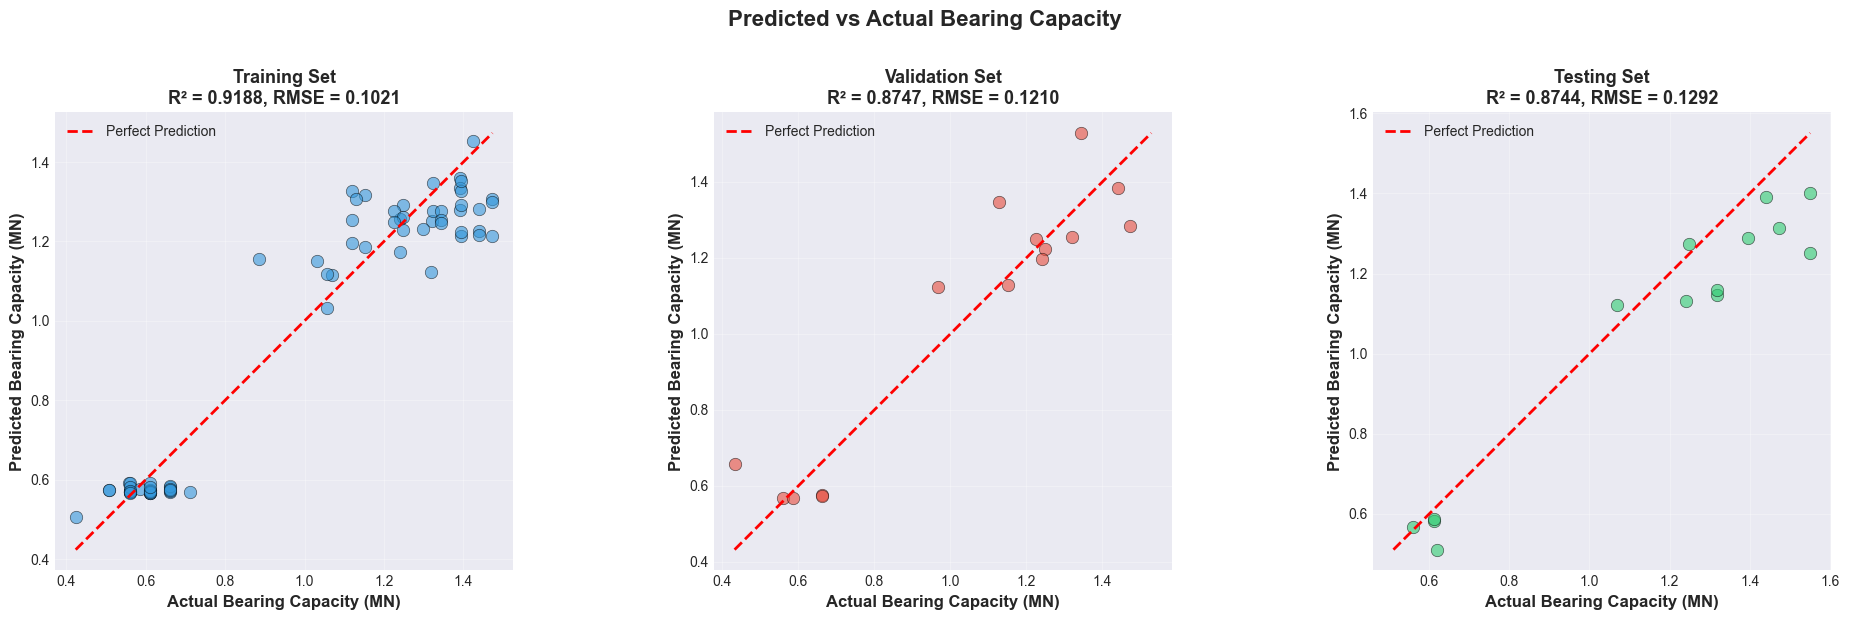

In [17]:
# Predicted vs Actual for all three sets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets_plot = [
    (y_train_true, y_train_pred, 'Training', train_r2, train_rmse, '#3498db'),
    (y_val_true, y_val_pred, 'Validation', val_r2, val_rmse, '#e74c3c'),
    (y_test_true, y_test_pred, 'Testing', test_r2, test_rmse, '#2ecc71')
]

for idx, (y_true, y_pred, name, r2, rmse, color) in enumerate(datasets_plot):
    axes[idx].scatter(y_true, y_pred, alpha=0.6, s=80, edgecolors='black',
                     linewidths=0.5, color=color)

    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val],
                  'r--', lw=2, label='Perfect Prediction')

    axes[idx].set_xlabel('Actual Bearing Capacity (MN)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Predicted Bearing Capacity (MN)', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{name} Set\nR² = {r2:.4f}, RMSE = {rmse:.4f}',
                       fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Bearing Capacity', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()